<a href="https://colab.research.google.com/github/nika19du/LangGraph-Agent-Workflows/blob/master/Multi_Agent_AI_Developer_Assistant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install dependentcies

In [1]:
!pip install -q langgraph langchain langchain-openai langchain-anthropic langchain-community wikipedia arxiv tavily-python

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 52.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [2]:
!pip install -q langchain-tavily

In [3]:
!pip install -q chromadb langchain-chroma

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.7/95.7 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the sou

## Imports

In [4]:
import os
import subprocess

from html import escape
from IPython.display import Image, HTML, display
from google.colab import userdata
from langgraph.graph.message import add_messages
from pathlib import Path
from pydantic import BaseModel, Field, SecretStr
from typing import Annotated, List, TypedDict, Literal
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.runnables import Runnable

from langchain_core.messages import HumanMessage, SystemMessage,BaseMessage
from langchain_core.tools import tool
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_openai import ChatOpenAI
from langchain_anthropic import ChatAnthropic

from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.types import Command, Interrupt, Send, interrupt
from langchain.agents import create_agent

from langchain_community.utilities import (
    WikipediaAPIWrapper,
    ArxivAPIWrapper
)

from langchain_community.tools import (
    WikipediaQueryRun,
    ArxivQueryRun
)

from langchain_tavily import TavilySearch


/tmp/ipykernel_3423/1054603372.py:18: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import TextLoader


## API Keys

In [5]:
openai_api_key = SecretStr(userdata.get('OPENAI_API_KEY'))

anthropic_api_key = userdata.get("ANTHROPIC_API_KEY")

tavily_api_key = userdata.get("TAVILY_API_KEY")
os.environ["TAVILY_API_KEY"] = tavily_api_key

## Model Configuration

- The coding model generates and revises code.
- The reviewer model independently evaluates proposed implementations.

In [6]:
coding_model = ChatOpenAI(
    model = "gpt-5.6-luna",
    api_key=openai_api_key,
    reasoning_effort="none"
)

review_model=ChatAnthropic(
    model="claude-sonnet-4-6",
    api_key= anthropic_api_key
)

## Knowledge Base & RAG

In [7]:
KNOWLEDGE_FILE = Path(
    "/content/developer_assistant_knowledge.md"
)

if not KNOWLEDGE_FILE.exists():
    raise FileNotFoundError(
        "Upload developer_assistant_knowledge.md "
        "to the Colab runtime before running this cell."
    )

loader = TextLoader(
    str(KNOWLEDGE_FILE),
    encoding="utf-8"
)

documents = loader.load()

print(
    f"Loaded documents: {len(documents)}"
)

Loaded documents: 1


In [8]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=800,
    chunk_overlap=120,
    separators=[
        "\n## ",
        "\n### ",
        "\n\n",
        "\n",
        " ",
        ""
    ]
)

chunks = text_splitter.split_documents(documents)

print(f"Documents: {len(documents)}")

print(f"Chunks: {len(chunks)}")

Documents: 1
Chunks: 23


## Embeddings

Each knowledge-base chunk is converted into a numerical embedding.

Embedding make it possible to compare the semantic meaning of a user query with the stored documentation.

In [9]:
embeddings = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=openai_api_key
)

## Chroma Vector Store

The document chunks and their embeddings are stored in Chroma.

Chroma provides semantic search over the internal developer documentation.

In [10]:
vector_store = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="developer_assistant_knowledge"
)

print(
    f"Indexed chunks: {len(chunks)}"
)

Indexed chunks: 23


## Retriever

The retriever returns the most semantically relevant knowledge-base chunk for a query.

In [11]:
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={
        "k": 4
    }
)

## Internal Knowledge Tool

The internal search tool exposes the Chroma retriever to the agent.

It is used when a question depends on project-specific engineering guidelines or internal documentation.  

In [12]:
@tool
def search_knowledge_base(query: str) -> str:
    """
    Search the internal developer knowledge base.

    Use this tool for project-specific engineering guidelines,
    coding standards, testing conventions, architecture,
    error-handling rules, and internal developmennt policies.

    Args:
        query: Semantic search query.

    Returns:
        Relevant passages from the internal knowledge base.
    """

    documents = retriever.invoke(query)

    if not documents:
        return (
            "No relevant information was found "
            "in the internal knowledge base."
        )

    results = []

    for index, document in enumerate(documents, start =1):
        results.append(
            f"""
          Result {index}
          ---------
          {document.page_content}
          """.strip()
        )

    return "\n\n".join(results)


## Knowledge Subgraph

## Shared Utilities

In [13]:
def display_graph(runnable: Runnable, output_png: Path) -> None:
    with output_png.open(mode="wb") as file:
        file.write(runnable.get_graph().draw_mermaid_png())

    display(Image(output_png, format="png"))

def print_interrupts(interrupts: List[Interrupt]):
    for interrupt_item in interrupts:
        value = interrupt_item.value

        workflow_status = str(
            value.get("workflow_status", "")
        )

        # 1. Missing file path
        if workflow_status == "waiting_for_file_path":
            message = escape(
                str(value.get("message", ""))
            )

            display(
                HTML(
                    f"""
                    <div style="
                        border: 1px dashed orange;
                        margin: 10px 0;
                        padding: 15px;
                    ">
                        <h3>Input Required</h3>

                        <p><b>{message}</b></p>

                        <p>
                            <b>Workflow Status:</b>
                            waiting_for_file_path
                        </p>

                        <p>
                            Provide a valid file path,
                            for example:
                            <code>/content/example.py</code>
                        </p>
                    </div>
                    """
                )
            )

        # 2. Human approval
        elif workflow_status == "pending_human_approval":
            message = escape(
                str(value.get("message", ""))
            )

            proposed_content = escape(
                str(value.get("proposed_content", ""))
            )

            review = value.get("review", {})

            status = escape(
                str(review.get("status", ""))
            )

            score = escape(
                str(review.get("score", ""))
            )

            issues = escape(
                str(review.get("issues", []))
            )

            feedback = escape(
                str(review.get("feedback", ""))
            )

            revision_count = escape(
                str(value.get("revision_count", 0))
            )

            display(
                HTML(
                    f"""
                    <div style="
                        border: 1px dashed red;
                        margin: 10px 0;
                        padding: 15px;
                    ">
                        <h3>Human Review Required</h3>

                        <p><b>{message}</b></p>

                        <h4>Proposed Content</h4>
                        <pre>{proposed_content}</pre>

                        <p>
                            <b>Workflow Status:</b>
                            pending_human_approval
                        </p>

                        <h4>AI Review</h4>

                        <p>
                            <b>AI Review Status:</b>
                            {status}
                        </p>

                        <p>
                            <b>AI Review Score:</b>
                            {score}/10
                        </p>

                        <p>
                            <b>Issues:</b>
                            {issues}
                        </p>

                        <p>
                            <b>Feedback:</b>
                            {feedback}
                        </p>

                        <p>
                            <b>Revisions so far:</b>
                            {revision_count}
                        </p>

                        <p>
                            Resume with
                            <code>approve</code>
                            or provide revision feedback.
                        </p>
                    </div>
                    """
                )
            )

## Coding Subgraph
The coding subgraph handles code generation and code modification.

It contains:
  - a coding agent;
  - file and execution tools;
  - an independent reviewer agent;
  - human approval;
  - a revision loop;
  - a controlled file-write step.

###  Coding State and Structured Output:

>> CodingState stores the data required during the coding workflow.

>> ReviewResult defines the structured output produced by the reviewer agent.



In [14]:
class ReviewResult(BaseModel):
    status: Literal["approved","changes_required"] = Field(description="Whether the proposed solution is approved or needs revision.")
    score: int = Field(ge=1, le= 10, description="Overall code quality score from 1 to 10.")
    issues: list[str] = Field(default_factory= list, description="Problems found in the proposed implementation.")
    feedback: str = Field(default="", description = "Specific instructions for the coding agent if revision is needed.")


class CodingState(TypedDict):
    user_request: str
    task_type: Literal['create', 'modify']

    file_path:str
    proposed_content: str

    review: dict | None #ReviewResult | None

    human_feedback: str
    ai_revision_count: int
    human_revision_count: int
    final_answer: str

    messages: Annotated[list[BaseMessage], add_messages]


structured_review_model = review_model.with_structured_output(ReviewResult)

## Coding Tools

In [15]:
@tool
def read_file(file_path: str) -> str:
    """
    Read a text-based file from the Google Colab enviornment.

    Args:
        file_path: Absolute or relative path to the file.

    Returns:
        The file content as a string.
    """

    path = Path(file_path)

    if not path.exists():
        return f"Error: File '{file_path}' not found."

    if not path.is_file():
        return f"Error: '{file_path}' is not a file."

    try:
      with path.open(mode="r", encoding = "utf-8") as file:
          return file.read()
    except Exception as e:
        return f"Error: Could not read file: {e}"


@tool
def write_file(file_path: str, content: str) -> str:
    """
    Write approved text content to a file in the Google Colab environment.

    This tool should only be used after human approval.

    Args:
      file_path: Path to the target file.
      content: Full content that should be written.

    Returns:
      A status message.
    """

    path = Path(file_path)

    try:
        path.parent.mkdir(
            parents = True,
            exist_ok = True
        )

        path.write_text(
            content,
            encoding="utf-8"
        )

        return f"Success: File '{file_path}' was updated."

    except Exception as e:
          return f"Error: Could not write file: {e}"

@tool
def run_python_file(file_path: str) -> str:
    """
    Execute a Python file and return stdout, stderr and exit code.

    Args:
        file_path: Path to a Python file.

    Returns:
        Execution result.
    """

    path = Path(file_path)

    if not path.exists():
        return f"ERROR: File '{file_path}' does not exist."

    if path.suffix != ".py":
        return "ERROR: Only Python files can be executed."

    try:
        result = subprocess.run(
            ["python", str(path)],
            capture_output=True,
            text=True,
            timeout=10
        )

        return (
            f"Exit code: {result.returncode}\n\n"
            f"STDOUT:\n{result.stdout}\n"
            f"STDERR:\n{result.stderr}"
        )

    except subprocess.TimeoutExpired:
        return "ERROR: Execution exceeded the 10 second timeout."

    except Exception as e:
        return f"ERROR: Could not execute file: {e}"

In [16]:
coding_tools = [
    search_knowledge_base,
    read_file,
    run_python_file
]

## Agent Prompts

In [17]:
CODING_SYSTEM_PROMPT = """
You are a senior software engineer.

You can work with multiple programming languages, including Python,
C#, Java, JavaScript, and TypeScript.

Determine the programming language from:
- the user's explicit request;
- the file extension;
- the existing file content.

Your task is to create or modify code based on the user's request.

Use search_knowledge_base when project-specific engineering guidelines,
coding standards, testing conventions, error-handling rules, or review
policies are relevant.

If the task is to modify an existing file:
- use read_file to inspect the current content;
- preserve the programming language and existing project style;
- use search_knowledge_base when internal guidelines may affect the solution;
- do not write directly to the file;
- return the full proposed updated content.

If the task is to create new code:
- generate the complete implementation in the requested language;
- consult the internal knowledge base when useful.

If reviewer or human feedback is available:
- revise the previous proposal accordingly.

Use run_python_file only when the target file is a Python file.

Do not call tools unnecessarily.

IMPORTANT OUTPUT RULE:
When you have finished using tools and are returning the proposed
implementation, return ONLY the complete file content.

Do not include:
- Markdown code fences;
- explanations;
- "Before" or "After" sections;
- descriptions of the applied guidelines;
- commentary outside the code.

The final response will be written directly to a file after human
approval, so it must contain only valid file content.
"""

REVIEWER_SYSTEM_PROMPT = """
You are a strict senior software engineer performing a code review.

Review the proposed implementation against the original user request.

Evaluate:
- correctness
- edge cases
- readability
- maintainability
- potential bugs
- whether the implementation fully satisfies the request

Give a score from 1 to 10.

Use status "approved" only if the implementation is correct and does not
require meaningful changes.

Use status "changes_required" if changes are necessary.

When changes are required:
- list the identified issues;
- provide specific and actionable feedback for the coding agent.
"""

In [18]:
coding_agent_executor = create_agent(
    model = coding_model,
    tools = coding_tools,
    system_prompt = CODING_SYSTEM_PROMPT
)

## Coding Agent

In [19]:
def strip_code_fences(content: str) -> str:
    content = content.strip()

    if content.startswith("```"):
        lines = content.splitlines()

        if lines[0].startswith("```"):
            lines = lines[1:]

        if lines and lines[-1].strip() == "```":
            lines = lines[:-1]

        return "\n".join(lines)

    return content

In [20]:
def coding_agent(state: CodingState):
    context_message = HumanMessage(
        content=f"""
                User request:
                {state["user_request"]}

                Task type:
                {state["task_type"]}

                File path:
                {state.get("file_path", "")}

                Reviewer feedback:
                {state.get("review", {}).get("feedback", "") if state.get("review") else ""}

                Human feedback:
                {state.get("human_feedback", "")}
                """
    )


    result = coding_agent_executor.invoke({
        "messages": [
            context_message
        ]
    })

    final_message = result["messages"][-1]

    return {
        "messages": [final_message],
        "proposed_content": strip_code_fences(final_message.content)
    }

## Reviewer Agent

In [21]:
def code_reviewer(state: CodingState):
    messages= [
        SystemMessage(content = REVIEWER_SYSTEM_PROMPT),
        HumanMessage(
            content=f"""
                Original user request:
                {state["user_request"]}

                Proposed implementation:
                {state["proposed_content"]}
            """
        )
    ]

    review = structured_review_model.invoke(messages)

    return {
        "review": review.model_dump()
    }

In [22]:
def increment_ai_revision(state: CodingState):
    return {
        "ai_revision_count": state.get('ai_revision_count', 0) + 1
    }

def increment_human_revision(state: CodingState):
    return {
        "human_revision_count": state.get('human_revision_count', 0) + 1
}

## Human-in-the-Loop

In [23]:
def human_review(state: CodingState):
    decision = interrupt({
        "message": "The solution passed AI review. Approve it or provide feedback.",
        "workflow_status": "pending_human_approval",
        "proposed_content": state["proposed_content"],
        "review": state["review"],
        "ai_revision_count": state.get("ai_revision_count", 0),
        "human_revision_count": state.get("human_revision_count", 0)
    })

    update = {
        "human_feedback": decision
    }

    return update


def save_file(state: CodingState):
    if state["task_type"] != "modify":
        return {
            "final_answer": "Workflow completed. The proposed code was approved."
        }

    result = write_file.invoke({
        "file_path": state["file_path"],
        "content": state["proposed_content"]
    })

    return {
        "final_answer": f"Workflow completed. {result}"
    }

## Routing Functions

In [24]:
def route_after_review(state: CodingState):
    if state["review"]["status"] == "changes_required":
        return "revise"

    return "approved"

def route_after_human(state: CodingState):
    feedback = state["human_feedback"].strip().lower()

    if feedback in {"approve", "approved", "yes"}:
        return "approved"

    return "revise"

## Build Coding Subgraph

In [26]:
coding_builder = StateGraph(CodingState)

coding_builder.add_node('coding_agent', coding_agent)
coding_builder.add_node('reviewer', code_reviewer)
coding_builder.add_node('increment_ai_revision', increment_ai_revision)
coding_builder.add_node('human_review', human_review)
coding_builder.add_node('increment_human_revision', increment_human_revision)
coding_builder.add_node("save_file", save_file)

coding_builder.add_edge(START, "coding_agent")

coding_builder.add_edge("coding_agent", "reviewer")

coding_builder.add_conditional_edges(
    "reviewer",
    route_after_review,
    {
        "approved": "human_review",
        "revise": "increment_ai_revision"
    }
)

# count ai-requested revision
coding_builder.add_edge("increment_ai_revision", "coding_agent")

# human review: save or human revision
coding_builder.add_conditional_edges(
    "human_review",
    route_after_human,
    {
        "approved": "save_file",
        "revise": "increment_human_revision"
    }
)

# count human-requested revision
coding_builder.add_edge("increment_human_revision", "coding_agent")

coding_builder.add_edge("save_file", END)

coding_subgraph = coding_builder.compile(debug = True)

## Visualization

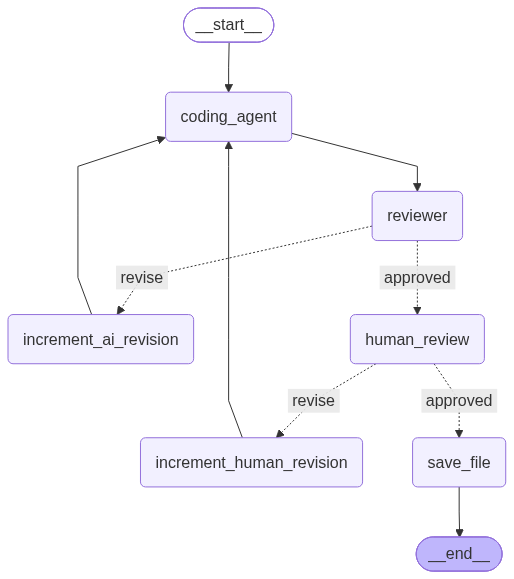

In [27]:
display_graph(
    coding_subgraph,
    Path("coding_subgraph.png")
)

In [28]:
class KnowledgeState(TypedDict):
  user_request: str
  final_answer: str
  messages: Annotated[list[BaseMessage], add_messages]

## External Knowledge Tools

In [29]:
wikipedia_tool = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=3000
    )
)

arxiv_tool = ArxivQueryRun(
    api_wrapper=ArxivAPIWrapper(
        top_k_results=2,
        doc_content_chars_max=3000
    )
)

web_search_tool = TavilySearch(
    max_results=3
)

In [30]:
knowledge_tools = [
    search_knowledge_base,
    wikipedia_tool,
    arxiv_tool,
    web_search_tool
]

## Prompt

In [31]:
KNOWLEDGE_SYSTEM_PROMPT = """
You are a software-development research assistant.

Your task is to answer informational questions using the most
appropriate available source.

Available tools:

1. search_knowledge_base
   Use for internal or project-specific information such as:
   - coding standards;
   - software engineering guidelines;
   - testing conventions;
   - architecture rules;
   - error-handling policies;
   - code-review rules;
   - development workflow documentation.

2. Wikipedia
   Use for general encyclopedic or historical knowledge.

3. arXiv
   Use for scientific papers, academic research,
   machine learning research, and technical publications.

4. Web search
   Use for recent, changing, or current information.

Choose the tool that best matches the question.

You may use multiple tools when necessary.

Do not use external tools when the question is specifically about
internal project documentation.

After gathering sufficient information, provide a clear synthesized
answer to the user's original question.
"""

In [32]:
knowledge_agent_executor = create_agent(
    model=coding_model,
    tools=knowledge_tools,
    system_prompt=KNOWLEDGE_SYSTEM_PROMPT
)

## Knowledge Agent

In [33]:
def knowledge_agent(state: KnowledgeState):
    result = knowledge_agent_executor.invoke({
        "messages": [
            HumanMessage(content = state["user_request"])
        ]
    })

    final_message = result["messages"][-1]

    return {
        "messages": [final_message],
        "final_answer": final_message.content
    }

## Build Knowledge Subgraph

In [34]:
knowledge_builder = StateGraph(KnowledgeState)

knowledge_builder.add_node('knowledge_agent', knowledge_agent)

knowledge_builder.add_edge(START, "knowledge_agent")

knowledge_builder.add_edge("knowledge_agent", END)

knowledge_subgraph = knowledge_builder.compile()

## Visualization

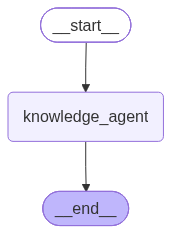

In [35]:
display_graph(knowledge_subgraph,Path("knowledge_subgraph.png"))

## Main Workflow

## Main State

In [36]:
class MainState(TypedDict):
    user_request: str
    intent: Literal['chat', 'knowledge', 'code']
    task_type: Literal['create', 'modify'] | None
    file_path: str

    original_content: str
    proposed_content: str
    review: dict | None
    human_feedback: str
    ai_revision_count: int
    human_revision_count: int

    final_answer: str
    messages: Annotated[list[BaseMessage], add_messages]

## Classification Schema

In [37]:
class ClassificationResult(BaseModel):
    intent: Literal['chat', 'knowledge', 'code'] = Field(
        description = "The type of the user's request."
    )

    task_type: Literal['create', 'modify'] | None = Field(
        default = None,
        description="For coding requests, whether code should be created or an existing file modified."
    )

    file_path: str = Field(
        default = "",
    )

## Classifier Agent

In [38]:
classifier_model = coding_model.with_structured_output(ClassificationResult)

CLASSIFIER_SYSTEM_PROMPT = """
Classify the user's request into exactly one category:

chat:
General conversation that does not require
external research or code generation.

knowledge:
An informational or research question that
should be handled by the knowledge workflow.

code:
A request to create software code or modify
an existing code file.

For code requests:
- task_type="create" when new code should be generated;
- task_type="modify" when an existing file should be changed;
- extract file_path only when the user explicitly provides one.

Programming language does not affect the intent classification.

Return only the structured classification.
"""

def classifier(state: MainState):
    classification = classifier_model.invoke([
        SystemMessage(content=CLASSIFIER_SYSTEM_PROMPT),
        HumanMessage(content=state["user_request"])
    ])

    return {
        "intent": classification.intent,
        "task_type": classification.task_type,
        "file_path": classification.file_path
    }

## Chat Agent

In [39]:
CHAT_SYSTEM_PROMPT = """
You are a helpful conversational assistant.

Respond naturally and concisely to general user messages.
Do not use coding tools or knowledge retrieval for simple conversation.
"""

def chat_agent(state: MainState):
    response = coding_model.invoke([
        SystemMessage(content=CHAT_SYSTEM_PROMPT),
        HumanMessage(content=state["user_request"])
    ])

    return {
        "final_answer": response.content,
        "messages": [response]
    }

## Missing File Path HITL

When the classifier identifies a code modification request but the user has no provided a file path, the workflow pauses and asks the user for the missing information.

The workflow is later resumed using `Command(resume=...)`.

In [40]:
def request_file_path(state: MainState):
    file_path = interrupt({
        "message": "Please provide the path of the file you want to modify.",
        "workflow_status": "waiting_for_file_path"
    })

    return {
        "file_path": str(file_path).strip()
    }

## Main Routing

the classifier determines the request type, while a deterministic routing function selects the corresponding workflow.

A modification request without a file path is routed to the missing-information HITL node before entering the coding subgraph

In [41]:
def route_after_classifier(state: MainState):
    intent = state["intent"]

    if intent == "chat":
        return "chat"

    if intent == "knowledge":
        return "knowledge"

    if intent == "code":
        if (state["task_type"] == "modify" and not state.get("file_path")):
            return "missing_file_path"

        return "code"

    raise ValueError(f"Unsupported intent: {intent}")

## Build Main Graph

The main graph orchestrates the three application paths:

- **Chat**: conversational agent
- **Knowledge**: knowledge and RAG subgraph
- **Code**: coding and review subgraph

The parent graph owns the checkpointer. This allows workflow state to persist accross interruptions and enables human-in-the-loop resume behavior.

In [42]:
main_builder = StateGraph(MainState)

main_builder.add_node('classifier', classifier)
main_builder.add_node('chat_agent', chat_agent)
main_builder.add_node('knowledge_workflow', knowledge_subgraph)
main_builder.add_node('coding_workflow', coding_subgraph)
main_builder.add_node('request_file_path', request_file_path)

main_builder.add_edge(START, "classifier")

main_builder.add_conditional_edges(
    "classifier",
    route_after_classifier,
    {
        "chat": "chat_agent",
        "knowledge": "knowledge_workflow",
        "code": "coding_workflow",
        "missing_file_path": "request_file_path"
    }
)

main_builder.add_edge("request_file_path", "coding_workflow")

main_builder.add_edge("chat_agent", END)
main_builder.add_edge("knowledge_workflow", END)
main_builder.add_edge("coding_workflow", END)

main_checkpointer = InMemorySaver()

main_graph = main_builder.compile(
    checkpointer = main_checkpointer,
    debug = True
)

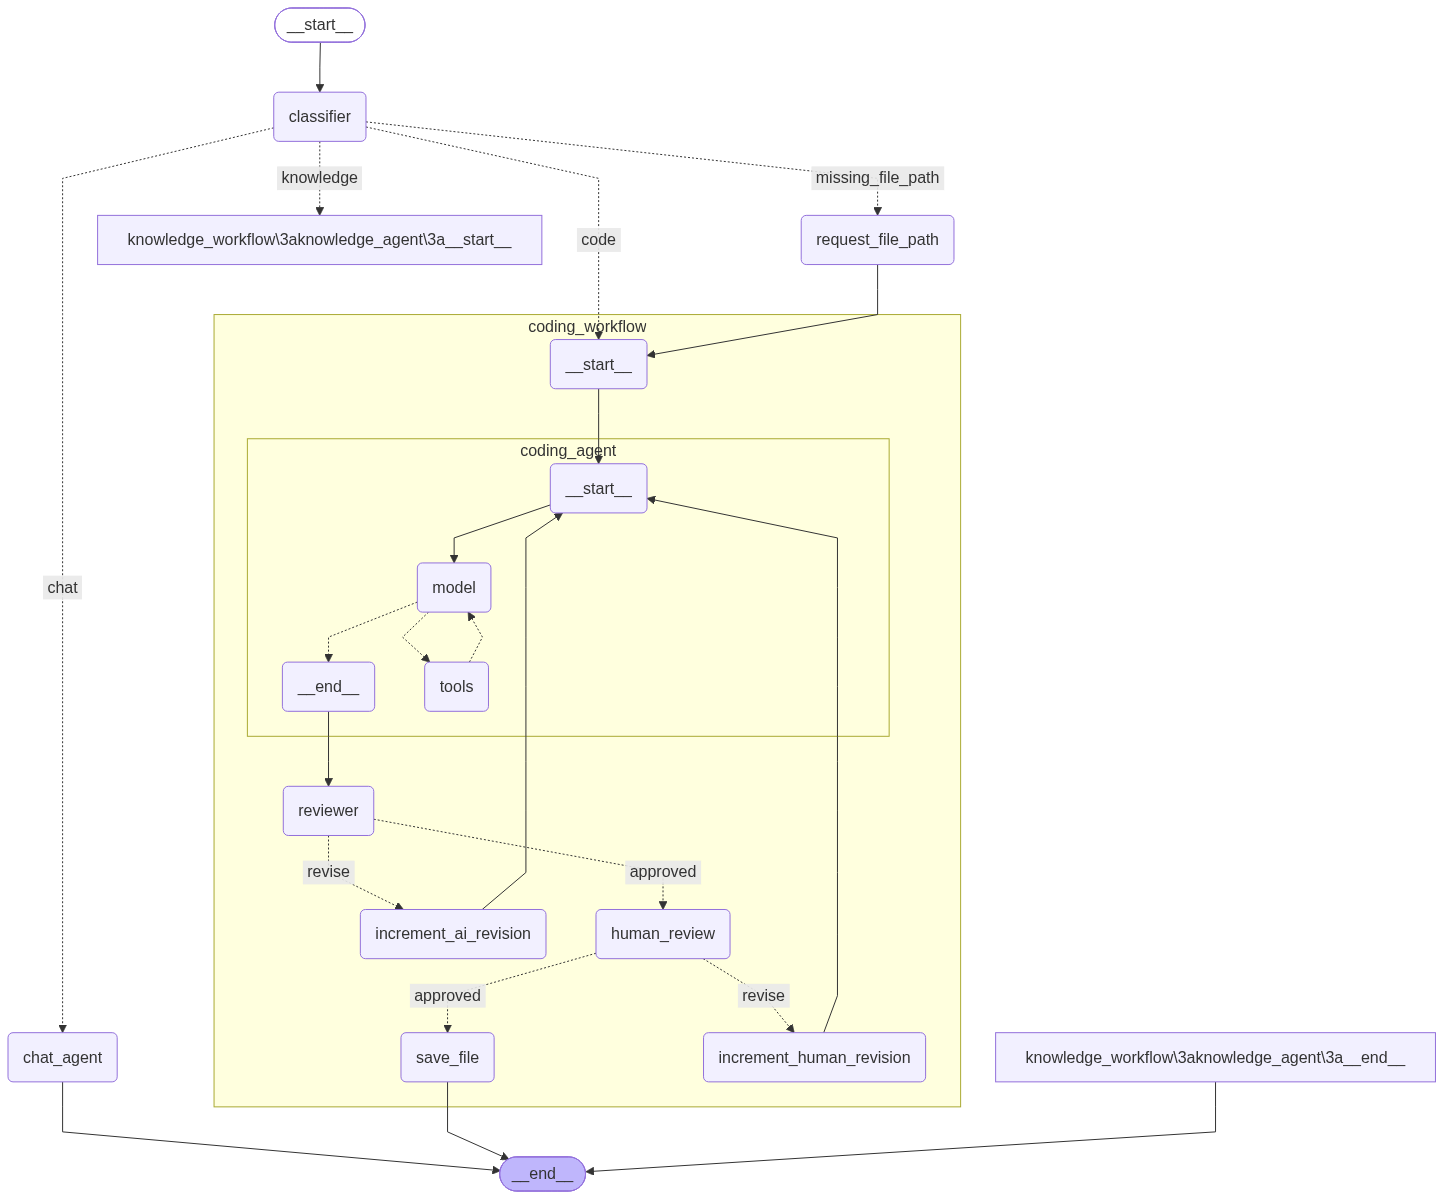

In [43]:
display(Image(main_graph.get_graph(xray=True).draw_mermaid_png()))

In [44]:
def get_human_input(interrupts: List[Interrupt]) -> str:
    interrupt_value = interrupts[0].value

    workflow_status = interrupt_value.get(
        "workflow_status"
    )

    if workflow_status == "waiting_for_file_path":
        return input(
            "\nEnter file path: "
        ).strip()

    if workflow_status == "pending_human_approval":
        return input(
            "\nType 'approve' or provide revision feedback: "
        ).strip()

    return input(
        "\nProvide input: "
    ).strip()

## Workflow Execution

In [45]:
def execute_workflow(user_request: str, thread_id: str = "default-thread"):
    config = {
        "configurable": {
            "thread_id": thread_id
        }
    }

    initial_state = {
        "user_request": user_request,

        "intent": "chat",

        "task_type": None,
        "file_path": "",

        "proposed_content": "",
        "review": None,

        "human_feedback": "",
        "ai_revision_count": 0,
        "human_revision_count": 0,

        "final_answer": "",

        "messages": []
    }

    result = main_graph.invoke(
        initial_state,
        config=config
    )

    while "__interrupt__" in result:
      interrupts = result["__interrupt__"]

      print_interrupts(interrupts)

      human_decision = get_human_input(
          interrupts
      )

      if not human_decision:
          print("Input cannot be empty.")
          continue

      result = main_graph.invoke(
          Command(resume=human_decision),
          config=config
      )

    return result

## Test Cases

In [46]:
create_result = execute_workflow(
    user_request=(
        "Create a C# method that calculates "
        "the factorial of a non-negative integer "
        "following our internal development guidelines."
    ),
    thread_id="test-csharp-rag"
)

print(create_result["final_answer"])

[values] {'user_request': 'Create a C# method that calculates the factorial of a non-negative integer following our internal development guidelines.', 'intent': 'chat', 'task_type': None, 'file_path': '', 'original_content': '', 'proposed_content': '', 'review': None, 'human_feedback': '', 'revision_count': 0, 'final_answer': '', 'messages': []}
[updates] {'classifier': {'intent': 'code', 'task_type': 'create', 'file_path': ''}}
[values] {'user_request': 'Create a C# method that calculates the factorial of a non-negative integer following our internal development guidelines.', 'intent': 'code', 'task_type': 'create', 'file_path': '', 'original_content': '', 'proposed_content': '', 'review': None, 'human_feedback': '', 'revision_count': 0, 'final_answer': '', 'messages': []}
[values] {'user_request': 'Create a C# method that calculates the factorial of a non-negative integer following our internal development guidelines.', 'task_type': 'create', 'file_path': '', 'original_content': '', 


Type 'approve' or provide revision feedback: approve
[values] {'user_request': 'Create a C# method that calculates the factorial of a non-negative integer following our internal development guidelines.', 'intent': 'code', 'task_type': 'create', 'file_path': '', 'original_content': '', 'proposed_content': '', 'review': None, 'human_feedback': '', 'revision_count': 0, 'final_answer': '', 'messages': []}
[values] {'user_request': 'Create a C# method that calculates the factorial of a non-negative integer following our internal development guidelines.', 'task_type': 'create', 'file_path': '', 'original_content': '', 'proposed_content': 'public static class MathUtilities\n{\n    public static long Factorial(int value)\n    {\n        if (value < 0)\n        {\n            throw new ArgumentOutOfRangeException(\n                nameof(value),\n                value,\n                "Value must be a non-negative integer.");\n        }\n\n        long result = 1;\n\n        checked\n        

In [47]:
test_file = Path("/content/example.py")

test_file.write_text(
    """
      def divide(a, b):
      return a / b
    """,
    encoding="utf-8"
)

print(test_file.read_text())


      def divide(a, b):
      return a / b
    


In [49]:
modify_result = execute_workflow(
    user_request=(
        "Modify /content/example.py so that division by zero "
        "is handled according to our internal development guidelines. "
        "Preserve the existing function."
    ),
    thread_id="test-modify-python"
)

print(modify_result["final_answer"])

[values] {'user_request': 'Modify /content/example.py so that division by zero is handled according to our internal development guidelines. Preserve the existing function.', 'intent': 'chat', 'task_type': None, 'file_path': '', 'original_content': '', 'proposed_content': '', 'review': None, 'human_feedback': '', 'revision_count': 0, 'final_answer': '', 'messages': []}
[updates] {'classifier': {'intent': 'code', 'task_type': 'modify', 'file_path': '/content/example.py'}}
[values] {'user_request': 'Modify /content/example.py so that division by zero is handled according to our internal development guidelines. Preserve the existing function.', 'intent': 'code', 'task_type': 'modify', 'file_path': '/content/example.py', 'original_content': '', 'proposed_content': '', 'review': None, 'human_feedback': '', 'revision_count': 0, 'final_answer': '', 'messages': []}
[values] {'user_request': 'Modify /content/example.py so that division by zero is handled according to our internal development gui

KeyboardInterrupt: 

In [ ]:
print(
    Path("/content/example.py").read_text(
        encoding="utf-8"
    )
)

## Test 1 - Chat

In [ ]:
chat_result = execute_workflow(
    user_request=(
        "Hello! How are you?"
    ),
    thread_id="test-chat"
)

print(
    chat_result["final_answer"]
)

## Test 2 - Internal Knowledge / RAG

In [ ]:
rag_result = execute_workflow(
    user_request=(
        "According to our internal "
        "development guidelines, how "
        "should errors be handled?"
    ),
    thread_id="test-internal-rag-2"
)

print(
    rag_result["final_answer"]
)

## Test 3 - External Knowledge

In [ ]:
external_result = execute_workflow(
    user_request=(
        "Who was Ada Lovelace and "
        "what is she known for?"
    ),
    thread_id="test-external-knowledge"
)

print(
    external_result["final_answer"]
)

## Test 4 - Create Code

In [ ]:
csharp_rag_result = execute_workflow(
    user_request=(
        "Create a C# method that validates a user's age. "
        "Follow our internal C# coding, error-handling, "
        "and testing guidelines."
    ),
    thread_id="test-csharp-rag-3"
)

print(
    csharp_rag_result["final_answer"]
)

## Test 5 - Modify + Approve

In [ ]:
Path("/content/example.py").write_text(
    """
    def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

modify_result = execute_workflow(
    user_request=(
        "Modify /content/example.py "
        "to handle division by zero."
    ),
    thread_id="test-modify"
)

print(
    modify_result["final_answer"]
)

In [ ]:
print(
    Path(
        "/content/example.py"
    ).read_text(
        encoding="utf-8"
    )
)

## Test 6 - Revision

In [ ]:
Path("/content/example_revision.py").write_text(
    """def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

In [ ]:
revision_result = execute_workflow(
    user_request=(
        "Modify /content/example_revision.py "
        "to handle division by zero."
    ),
    thread_id="test-revision"
)

print(revision_result["final_answer"])

#Raise ZeroDivisionError explicitly and add a descriptive docstring.

## Missing Path

In [ ]:
Path("/content/missing_path_example.py").write_text(
    """def divide(a, b):
    return a / b
    """,
    encoding="utf-8"
)

In [ ]:
missing_path_result = execute_workflow(
    user_request=(
        "Modify the existing divide function "
        "so that it handles division by zero."
    ),
    thread_id="test-missing-path"
)

print(
    missing_path_result["final_answer"]
)